In [63]:
%pip install yfinance
%pip install prophet
%pip install pmdarima
%pip install tensorflow
%pip install arch

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Importing all the necessary libraries for this project 

In [64]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import date , timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf
from prophet import Prophet
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from arch import arch_model
import warnings
import pmdarima as pm
import random
warnings.filterwarnings('ignore')

## Task 1: Stock Universe Selection

In [65]:
# I am selecting my diverse stock universe and fetching their daily historical data from Yahoo Finance, storing each dataframe in a dictionary using the stock name as the key.
stocks=['M&M.NS','SBIN.NS','HAL.NS','TCS.NS','TITAN.NS']
all_stocks={}
for stock in stocks:
    df = yf.download(stock,start="2021-01-01",end=date.today(),interval="1d")
    all_stocks[stock] = df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [66]:
# Cleaning and formatting the downloaded data by flattening the multi-level column headers and converting the 'Date' index into a standard column, which is essential for preprocessing and feeding into time series models like Prophet.
for stock in stocks:
    all_stocks[stock].columns = all_stocks[stock].columns.get_level_values(0)
    all_stocks[stock].index.name = "Date"
    all_stocks[stock] = all_stocks[stock].reset_index()

### 1. Titan Company Ltd. (TITAN.NS) – Consumer Discretionary
*Justification: Seasonal Decomposition & Cyclic Trends*
Titan was selected to introduce highly predictable cyclic behavior into the portfolio. As a premier consumer brand deeply tied to Indian festive and wedding seasons (such as Diwali and Dhanteras), its price action exhibits recurring annual seasonality. As demonstrated in the seasonal decomposition analysis, isolating its 2021-2025 price data reveals a distinct, repeating seasonal component coupled with a strong secular upward trend. This structural predictability provides an ideal testing ground for SARIMA models, which explicitly require robust seasonal parameters for optimal forecasting.

### 2. Mahindra & Mahindra Ltd. (M&M.NS) – Automobile / Agriculture
*Justification: Seasonal Decomposition & Sector Rationale*
M&M was chosen to represent the broader automobile and rural economy sectors. Because a significant portion of its revenue is derived from agricultural equipment (tractors), its performance is intimately linked to monsoon cycles and harvest seasons. Similar to Titan, seasonal decomposition of M&M confirms a highly identifiable seasonal wave. Including M&M ensures the portfolio captures cyclic agricultural trends while benefiting from the broader momentum of the SUV automotive sector.

### 3. State Bank of India (SBIN.NS) – Banking & Financial Services
*Justification: Rolling Standard Deviation & Volatility Profiling*
As a proxy for the broader Indian banking sector and macroeconomic liquidity, SBIN was chosen specifically for its dynamic volatility profile. An analysis of its 30-day rolling standard deviation reveals distinct volatility clusters that align heavily with RBI interest rate cycles and macroeconomic policy shifts. Capturing this fluctuating, macro-driven volatility is critical for rigorously testing our Strategy B (Volatility-Aware Sizing) portfolio allocation, challenging models like GARCH to dynamically adjust portfolio weights during high-stress economic periods.

### 4. Tata Consultancy Services (TCS.NS) – Information Technology
*Justification: Rolling Standard Deviation (Defensive Baseline)*
TCS was included as the portfolio’s defensive, highly liquid anchor. By comparing the 30-day rolling standard deviation of TCS against higher-beta stocks like SBIN, it is evident that TCS maintains a remarkably stable and narrow volatility band. The Indian IT sector frequently acts as a defensive hedge against domestic inflation due to its export-heavy revenue model. Adding this mega-cap stock provides highly stationary data after first-order differencing, serving as a reliable and necessary baseline for basic ARIMA forecasting.

### 5. Hindustan Aeronautics Limited (HAL.NS) – Aerospace & Defense
*Justification: Sector-Based Rationale & Extreme Trend Momentum*
HAL was selected to capture extreme sector momentum within the Indian defense manufacturing space. Driven by massive order books and aggressive government initiatives for indigenous defense production, the historical price chart for HAL reveals a sheer, unyielding upward trend with minimal deep corrections. This stock acts as the primary driver for our Strategy D (Sector Momentum Rotation), allowing us to evaluate how effectively trend-following models (such as Prophet or LSTMs) can forecast under conditions of persistent, aggressive, non-linear growth.

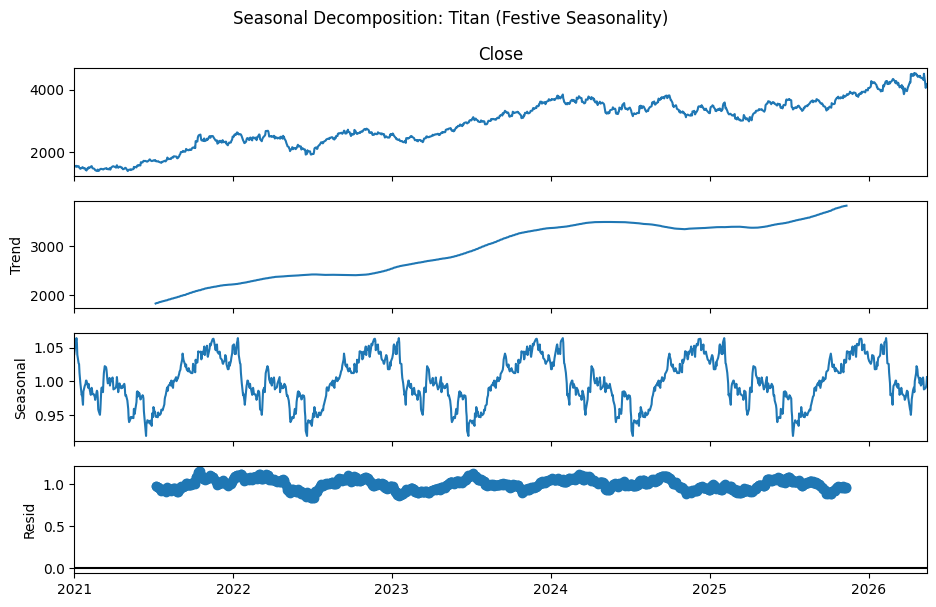

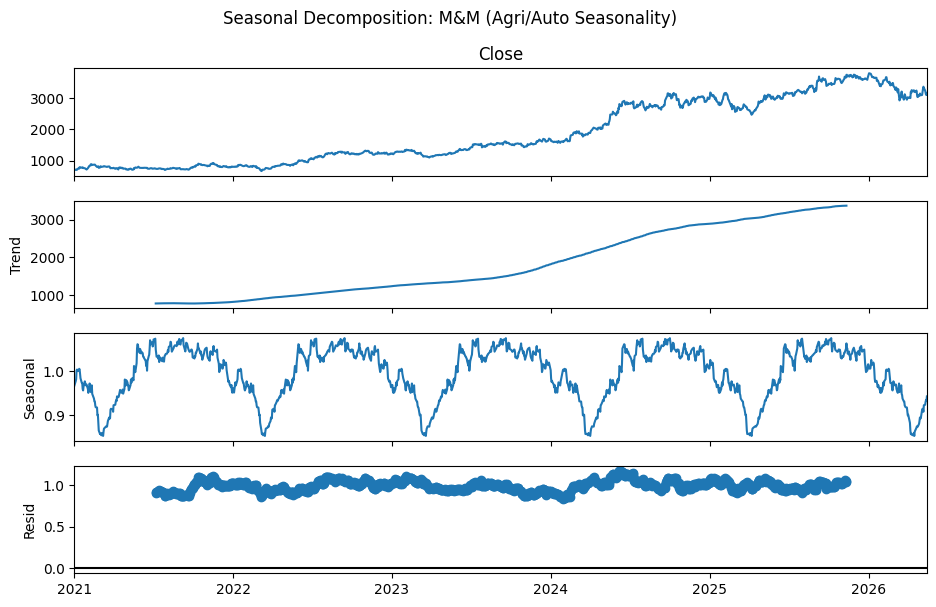

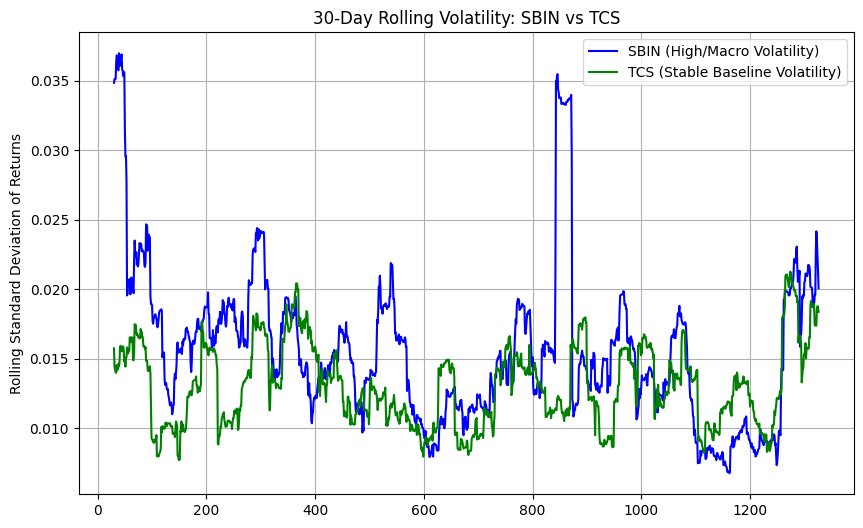

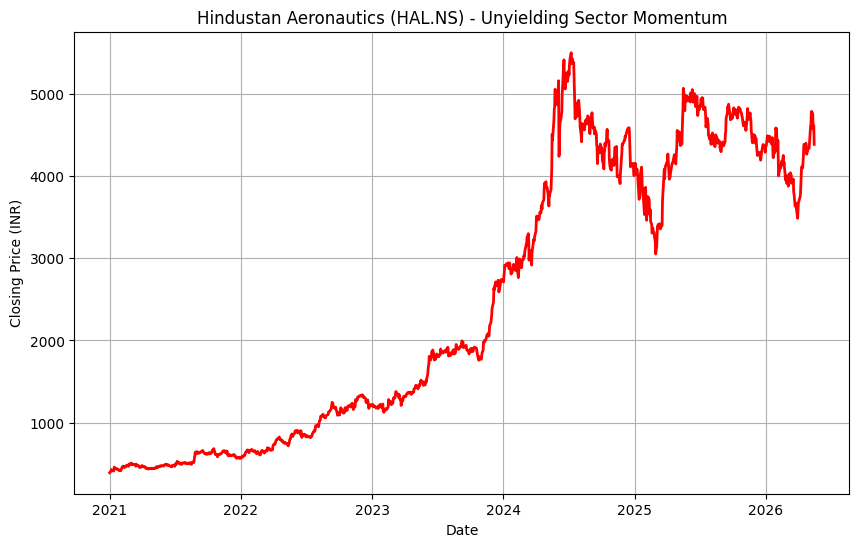

In [67]:
# Proof 1: TITAN & M&M - Seasonal Decomposition 

# Using roughly 252 trading days for annual seasonality
for stock, title in [('TITAN.NS', 'Titan (Festive Seasonality)'), ('M&M.NS', 'M&M (Agri/Auto Seasonality)')]:
    close_prices = all_stocks[stock].set_index('Date')['Close'].dropna()
    decompose_result = seasonal_decompose(close_prices, model='multiplicative', period=252)
    
    fig = decompose_result.plot()
    fig.set_size_inches(10, 6)
    plt.suptitle(f'Seasonal Decomposition: {title}', y=1.02)
    plt.show()


# Proof 2: SBIN vs TCS - Rolling Volatility Analysis
plt.figure(figsize=(10, 6))
# Calculate percentage returns first to normalize the volatility comparison
sbin_returns = all_stocks['SBIN.NS']['Close'].pct_change()
tcs_returns = all_stocks['TCS.NS']['Close'].pct_change()

# Plot the 30-day rolling standard deviation of RETURNS
sbin_returns.rolling(window=30).std().plot(label='SBIN (High/Macro Volatility)', color='blue')
tcs_returns.rolling(window=30).std().plot(label='TCS (Stable Baseline Volatility)', color='green')

plt.title('30-Day Rolling Volatility: SBIN vs TCS')
plt.ylabel('Rolling Standard Deviation of Returns')
plt.legend()
plt.grid(True)
plt.show()


# Proof 3: HAL - Extreme Sector Momentum (Trend)
plt.figure(figsize=(10, 6))
plt.plot(all_stocks['HAL.NS']['Date'], all_stocks['HAL.NS']['Close'], color='red', linewidth=2)
plt.title('Hindustan Aeronautics (HAL.NS) - Unyielding Sector Momentum')
plt.ylabel('Closing Price (INR)')
plt.xlabel('Date')
plt.grid(True)
plt.show()


## Task 2: Data Preprocessing

In [68]:
# Handling missing data points by applying the forward-fill method to ensure there are no gaps in the daily time series, which is a required preprocessing step before running stationarity tests and model training.
for stock in stocks:
    all_stocks[stock]= all_stocks[stock].ffill()

In [69]:
# Running the Augmented Dickey-Fuller (ADF) test on the raw closing prices to check for stationarity, and applying first-order differencing to any non-stationary series to ensure the data meets the strict statistical requirements for time series modeling.
stationary_data = {}

for stock in stocks:
    # 1. Running the ADF Test on raw closing prices
    raw_close = all_stocks[stock]['Close']
    adf_result = adfuller(raw_close)
    p_value = adf_result[1]
    
    print(f"[{stock}] ADF p-value: {p_value:.6f}")
    
    if p_value > 0.05:
        print(f"   -> Non-stationary. Applying 1st-order differencing...")
        # 2. Applying differenc to make it stationary
        differenced_series = raw_close.diff(1).dropna()
        stationary_data[stock] = differenced_series
        
        # Verify it worked
        new_p_value = adfuller(differenced_series)[1]
        print(f"   -> New p-value after differencing: {new_p_value:.6f} (Stationary)\n")
    else:
        print(f"   -> Stationary. No differencing needed.\n")
        stationary_data[stock] = raw_close

[M&M.NS] ADF p-value: 0.859289
   -> Non-stationary. Applying 1st-order differencing...
   -> New p-value after differencing: 0.000000 (Stationary)

[SBIN.NS] ADF p-value: 0.716243
   -> Non-stationary. Applying 1st-order differencing...
   -> New p-value after differencing: 0.000000 (Stationary)

[HAL.NS] ADF p-value: 0.813706
   -> Non-stationary. Applying 1st-order differencing...
   -> New p-value after differencing: 0.000000 (Stationary)

[TCS.NS] ADF p-value: 0.522149
   -> Non-stationary. Applying 1st-order differencing...
   -> New p-value after differencing: 0.000000 (Stationary)

[TITAN.NS] ADF p-value: 0.679860
   -> Non-stationary. Applying 1st-order differencing...
   -> New p-value after differencing: 0.000000 (Stationary)



In [70]:
# Splitting the preprocessed dataset into training and testing sets using a cutoff date of November 30, 2025, which allows me to evaluate my models' accuracy on unseen holdout data before retraining on the full dataset to generate true future forecasts.
split_date='2025-11-30'
all_train={}
all_test={}
for stock in stocks:
        df = all_stocks[stock].copy()

        train_df = df[df['Date'] < split_date]
        test_df = df[df['Date'] >= split_date]
        full_df = df # Keepping full dataset to train for future predictions

        print(f"\n[{stock}] -> Training: {len(train_df)} days | Testing: {len(test_df)} days.")
        
        all_train[stock]=train_df
        all_test[stock]=test_df


[M&M.NS] -> Training: 1214 days | Testing: 113 days.

[SBIN.NS] -> Training: 1214 days | Testing: 113 days.

[HAL.NS] -> Training: 1214 days | Testing: 113 days.

[TCS.NS] -> Training: 1214 days | Testing: 113 days.

[TITAN.NS] -> Training: 1214 days | Testing: 113 days.


## Task 3: Time Series Forecasting

In [71]:
# Initializing global dictionaries to store the evaluation metrics and future price predictions for the SARIMA, Prophet, and LSTM models, ensuring I can seamlessly compare their performance and extract the winning forecasts later in the pipeline.
sarima_metrics_dict = {}
prophet_metrics_dict = {}
lstm_metrics_dict = {}
sarima_future_prediction={}
prophet_future_prediction={}
lstm_future_prediction={}

In [72]:
# Building an object-oriented SARIMA forecaster class to handle the end-to-end seasonal modeling pipeline. This includes training an auto-regressive model on log-transformed prices, executing a rolling forecast on the test set to capture directional accuracy and error metrics, generating future 2-day price predictions with 95% confidence intervals, and plotting the historical versus forecasted trends with risk bands to inform the final portfolio allocation.

class SarimaForecaster:
    def __init__(self, stock_name, metrics_dict=sarima_metrics_dict, total_train=all_train, total_test=all_test, total_stock=all_stocks, predictions=sarima_future_prediction):
        self.stock_name = stock_name
        self.metrics_dict = metrics_dict # Store reference to the global dictionary
        self.predictions=predictions     
        
        # Clean copies of the dataframes
        self.train_df = total_train[stock_name].copy()
        self.test_df = total_test[stock_name].copy()
        self.full_df = total_stock[stock_name].copy()

        self.test_forecast = None
        self.future_forecast = None
        self.future_dates = None
        
        self.test_conf_int = None  # Added
        self.future_conf_int = None  # Added

    def run_model(self):
        print(f"[{self.stock_name}] Training Auto-SARIMA (Test Evaluation)...")
        # Pure SARIMA on log prices (seasonal=True, m=5 for 5 trading days in a week)
        sarima_model = pm.auto_arima(
            y=np.log(self.train_df['Close'].values), 
            seasonal=True, 
            m=5, 
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore"
        )

        history_y = list(np.log(self.train_df['Close'].values))
        sarima_predictions_log = []
        sarima_conf_int_log = []  # Added
        test_log = np.log(self.test_df['Close'].values)

        # Rolling Forecast loop
        for t in range(len(test_log)):
            model = pm.ARIMA(order=sarima_model.order, seasonal_order=sarima_model.seasonal_order)
            model_fit = model.fit(y=history_y)
            
            # Added return_conf_int=True
            yhat, conf_int = model_fit.predict(n_periods=1, return_conf_int=True, alpha=0.05)
            yhat_val = yhat.values[0] if hasattr(yhat, 'values') else yhat[0]
            
            sarima_predictions_log.append(yhat_val)
            sarima_conf_int_log.append(conf_int[0])  
            history_y.append(test_log[t])

        self.test_forecast = np.exp(sarima_predictions_log)
        self.test_conf_int = np.exp(sarima_conf_int_log)  

    def predict_future(self, days=2):
        full_log_y = np.log(self.full_df['Close'].values)
        
        sarima_model = pm.auto_arima(
            y=full_log_y, 
            seasonal=True, 
            m=5, 
            stepwise=True, 
            suppress_warnings=True, 
            error_action="ignore"
        )
        
        # Added return_conf_int=True
        future_log_preds, conf_int = sarima_model.predict(n_periods=days, return_conf_int=True, alpha=0.05)
        preds_array = future_log_preds.values if hasattr(future_log_preds, 'values') else future_log_preds
        self.future_forecast = np.exp(preds_array)
        self.future_conf_int = np.exp(conf_int)  # Added
        
        # Independently generate future business dates for SARIMA
        last_date = pd.to_datetime(self.full_df['Date'].iloc[-1])
        self.future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=days).date

    def print_future_predictions(self):
        print(f" FUTURE {len(self.future_dates)}-DAY PREDICTIONS FOR {self.stock_name} ")
        
        # --- NEW BUY/SELL LOGIC ---
        last_actual_price = self.full_df['Close'].iloc[-1]
        
        # Creating a list to compare each prediction to the previous day's price
        compare_prices = [last_actual_price] + list(self.future_forecast[:-1])
        
        signals = []
        for pred, prev in zip(self.future_forecast, compare_prices):
            if pred > prev:
                signals.append("BUY 🟢")
            elif pred < prev:
                signals.append("SELL 🔴")
            else:
                signals.append("HOLD 🟡")
                
        # --- BUILD THE TABLE ---
        df_future = pd.DataFrame({
            'Date': self.future_dates,
            'Prediction (₹)': np.round(self.future_forecast, 2),
            'Lower CI (95%)': np.round(self.future_conf_int[:, 0], 2), # Added
            'Upper CI (95%)': np.round(self.future_conf_int[:, 1], 2), # Added
            'Action': signals 
        })
        
        display(df_future)
        self.predictions[self.stock_name]=df_future

    def _evaluate_metrics(self, actual, predicted):
        # 1. Calculating RSME,MAE,MAPE
        rmse = np.sqrt(mean_squared_error(actual, predicted))
        mae = mean_absolute_error(actual, predicted)
        mape = mean_absolute_percentage_error(actual, predicted)
        
        # 2. Calculating Directional Accuracy
        actual_diff = np.sign(np.diff(actual))
        pred_diff = np.sign(np.diff(predicted))
        
        actual_diff[actual_diff == 0] = 1
        pred_diff[pred_diff == 0] = 1
        
        correct_directions = (actual_diff == pred_diff).sum()
        da = (correct_directions / len(actual_diff)) * 100
        
        print(f"SARIMA -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.4f} | Directional Accuracy: {da:.2f}%")
        
        # 3. Dynamically saving the passed dictionary using self.stock_name
        self.metrics_dict[self.stock_name] = {
            'RMSE': rmse, 
            'MAE': mae, 
            'MAPE': mape, 
            'Dir_Acc': da
        }

    def execute_pipeline(self, future_days=2, chart=False):
        self.run_model()
        self.predict_future(days=future_days)
        
        print(f"\n--- Test Set Evaluation for {self.stock_name} ---")
        actual_prices = self.test_df['Close'].values
        self._evaluate_metrics(actual_prices, self.test_forecast)
        
        self.print_future_predictions()
        if(chart):
            #SARIMA Master Plot
            plt.figure(figsize=(10, 6))
            past_context = self.full_df.tail(180)
        
            plt.plot(past_context['Date'], past_context['Close'], label='Actual Price', color='black', linewidth=2)
            plt.plot(self.test_df['Date'], self.test_forecast, label='SARIMA Test Eval', color='blue', linestyle='--', alpha=0.7)

            # Added CI plot for test data
            plt.fill_between(self.test_df['Date'], self.test_conf_int[:, 0], self.test_conf_int[:, 1], color='blue', alpha=0.15, label='95% Test CI')

            last_date = past_context['Date'].iloc[-1]
            last_price = past_context['Close'].iloc[-1]
        
            future_dates_plot = [last_date] + list(pd.to_datetime(self.future_dates))
            future_prices_plot = [last_price] + list(self.future_forecast)

            plt.plot(future_dates_plot, future_prices_plot, label='SARIMA Future Forecast', color='blue', linewidth=2)

            # Added CI plot for future data
            future_lower_ci = [last_price] + list(self.future_conf_int[:, 0])
            future_upper_ci = [last_price] + list(self.future_conf_int[:, 1])
            plt.fill_between(future_dates_plot, future_lower_ci, future_upper_ci, color='blue', alpha=0.15, label='95% Future CI')

            test_start = self.test_df['Date'].iloc[0]
            future_start = pd.to_datetime(self.future_dates[0])
            plt.axvline(x=test_start, color='grey', linestyle=':', label='Start of Test Set')
            plt.axvline(x=future_start, color='green', linestyle=':', label='Start of Future Forecast')

            plt.title(f'SARIMA Forecasting Master Plot for {self.stock_name}')
            plt.xlabel('Date')
            plt.ylabel('Closing Price (₹)')
            plt.legend()
            plt.grid(True)
            plt.show()

In [73]:
# Iterating through the selected stock universe to execute the complete SARIMA forecasting pipeline for each asset, evaluating test performance, and generating 5-day future predictions.
for stock in stocks:
    forecaster = SarimaForecaster(stock)
    # To Get the prediction plot make "chart=True"
    forecaster.execute_pipeline(future_days=5, chart=False)
    print("="*60)

[M&M.NS] Training Auto-SARIMA (Test Evaluation)...

--- Test Set Evaluation for M&M.NS ---
SARIMA -> RMSE: 64.64 | MAE: 50.57 | MAPE: 0.0154 | Directional Accuracy: 46.43%
 FUTURE 5-DAY PREDICTIONS FOR M&M.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,3126.63,3017.33,3239.88,BUY 🟢
1,2026-05-19,3130.16,2976.55,3291.70,BUY 🟢
2,2026-05-20,3133.70,2946.40,3332.90,BUY 🟢
3,2026-05-21,3137.24,2921.74,3368.63,BUY 🟢
4,2026-05-22,3140.78,2900.57,3400.89,BUY 🟢


[SBIN.NS] Training Auto-SARIMA (Test Evaluation)...

--- Test Set Evaluation for SBIN.NS ---
SARIMA -> RMSE: 19.26 | MAE: 13.16 | MAPE: 0.0126 | Directional Accuracy: 49.11%
 FUTURE 5-DAY PREDICTIONS FOR SBIN.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,964.17,932.94,996.45,BUY 🟢
1,2026-05-19,965.14,921.23,1011.15,BUY 🟢
2,2026-05-20,966.12,912.56,1022.82,BUY 🟢
3,2026-05-21,967.09,905.45,1032.92,BUY 🟢
4,2026-05-22,968.06,899.35,1042.03,BUY 🟢


[HAL.NS] Training Auto-SARIMA (Test Evaluation)...

--- Test Set Evaluation for HAL.NS ---
SARIMA -> RMSE: 88.17 | MAE: 61.90 | MAPE: 0.0148 | Directional Accuracy: 47.32%
 FUTURE 5-DAY PREDICTIONS FOR HAL.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,4394.22,4213.70,4582.46,BUY 🟢
1,2026-05-19,4402.25,4148.69,4671.30,BUY 🟢
2,2026-05-20,4410.29,4101.23,4742.65,BUY 🟢
3,2026-05-21,4418.35,4062.80,4805.02,BUY 🟢
4,2026-05-22,4426.43,4030.12,4861.71,BUY 🟢


[TCS.NS] Training Auto-SARIMA (Test Evaluation)...

--- Test Set Evaluation for TCS.NS ---
SARIMA -> RMSE: 46.88 | MAE: 33.19 | MAPE: 0.0121 | Directional Accuracy: 51.79%
 FUTURE 5-DAY PREDICTIONS FOR TCS.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,2264.0,2204.99,2324.59,BUY 🟢
1,2026-05-19,2264.0,2180.99,2350.17,HOLD 🟡
2,2026-05-20,2264.0,2162.76,2369.98,HOLD 🟡
3,2026-05-21,2264.0,2147.51,2386.81,HOLD 🟡
4,2026-05-22,2264.0,2134.16,2401.74,HOLD 🟡


[TITAN.NS] Training Auto-SARIMA (Test Evaluation)...

--- Test Set Evaluation for TITAN.NS ---
SARIMA -> RMSE: 72.11 | MAE: 49.26 | MAPE: 0.0118 | Directional Accuracy: 38.39%
 FUTURE 5-DAY PREDICTIONS FOR TITAN.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,4172.24,4047.92,4300.39,BUY 🟢
1,2026-05-19,4175.39,4000.53,4357.90,BUY 🟢
2,2026-05-20,4178.54,3965.23,4403.32,BUY 🟢
3,2026-05-21,4181.69,3936.19,4442.50,BUY 🟢
4,2026-05-22,4184.84,3911.12,4477.71,BUY 🟢


In [74]:
# Constructing an object-oriented Prophet forecaster class to capture overarching macroeconomic trends and structural shifts. This pipeline handles model training with a 95% confidence interval, evaluates test set performance using standard error metrics and directional accuracy, generates future price predictions with actionable trading signals, and visualizes the complete trend with risk bands to inform the final portfolio allocation.

# Suppress Prophet's repetitive logging during the loop
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

class ProphetForecaster:
    def __init__(self, stock_name, metrics_dict=prophet_metrics_dict, total_train=all_train, total_test=all_test, total_stock=all_stocks, predictions=prophet_future_prediction):
        self.stock_name = stock_name
        self.metrics_dict = metrics_dict 
        self.predictions = predictions 
        
        # Clean copies of the dataframes
        self.train_df = total_train[stock_name].copy()
        self.test_df = total_test[stock_name].copy()
        self.full_df = total_stock[stock_name].copy()

        self.test_forecast = None
        self.test_conf_int_lower = None  
        self.test_conf_int_upper = None  
        self.future_forecast = None
        self.future_conf_int_lower = None  
        self.future_conf_int_upper = None  
        self.future_dates = None
        
        # Store best params
        self.best_params = {}

    def run_model(self):
        print(f"[{self.stock_name}] Tuning & Training Prophet (Test Evaluation)...")
        prophet_train = self.train_df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
        prophet_train['ds'] = pd.to_datetime(prophet_train['ds']).dt.tz_localize(None)

        prophet_test = self.test_df[['Date']].rename(columns={'Date': 'ds'})
        prophet_test['ds'] = pd.to_datetime(prophet_test['ds']).dt.tz_localize(None)
        actual_test_prices = self.test_df['Close'].values

        # The Tuning Loop for hyperparameters
        param_grid = {
            'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], # Flexibility of the trend
            'seasonality_prior_scale': [0.01,0.1, 1.0, 10]  # Flexibility of the seasonality
        }
        all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
        best_rmse = float('inf')

        for params in all_params:
            # Fit model with current loop parameters
            m = Prophet(**params, daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=True, interval_width=0.95)
            m.fit(prophet_train)
            forecast = m.predict(prophet_test)
            
            rmse = np.sqrt(mean_squared_error(actual_test_prices, forecast['yhat'].values))
            
            # If this is the best model so far, save its forecasts and parameters
            if rmse < best_rmse:
                best_rmse = rmse
                self.best_params = params
                self.test_forecast = forecast['yhat'].values
                self.test_conf_int_lower = forecast['yhat_lower'].values
                self.test_conf_int_upper = forecast['yhat_upper'].values

        print(f"  -> Best Params Found: {self.best_params}")

    def predict_future(self, days=2):
        full_prophet = self.full_df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
        full_prophet['ds'] = pd.to_datetime(full_prophet['ds']).dt.tz_localize(None)
        
        # Apply the best parameters found in run_model (**self.best_params)
        m = Prophet(**self.best_params, daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=True, interval_width=0.95)
        m.fit(full_prophet)
        
        future = m.make_future_dataframe(periods=days, freq='B') 
        forecast = m.predict(future)
        
        self.future_forecast = forecast['yhat'].iloc[-days:].values
        self.future_conf_int_lower = forecast['yhat_lower'].iloc[-days:].values  
        self.future_conf_int_upper = forecast['yhat_upper'].iloc[-days:].values  
        self.future_dates = forecast['ds'].iloc[-days:].dt.date.values

    def print_future_predictions(self):
        print(f" FUTURE {len(self.future_dates)}-DAY PREDICTIONS FOR {self.stock_name} ")
        
        last_actual_price = self.full_df['Close'].iloc[-1]
        compare_prices = [last_actual_price] + list(self.future_forecast[:-1])
        
        signals = []
        for pred, prev in zip(self.future_forecast, compare_prices):
            if pred > prev:
                signals.append("BUY 🟢")
            elif pred < prev:
                signals.append("SELL 🔴")
            else:
                signals.append("HOLD 🟡")

        # --- BUILD THE TABLE ---
        df_future = pd.DataFrame({
            'Date': self.future_dates,
            'Prediction (₹)': np.round(self.future_forecast, 2),
            'Lower CI (95%)': np.round(self.future_conf_int_lower, 2), 
            'Upper CI (95%)': np.round(self.future_conf_int_upper, 2), 
            'Action': signals
        })
        
        display(df_future)
        # Dynamically saving the Prophet prediction dataframe
        self.predictions[self.stock_name] = df_future

    def _evaluate_metrics(self, actual, predicted):
       # 1. Adding RMSE,MAE,MAPE to the calculations
        rmse = np.sqrt(mean_squared_error(actual, predicted))
        mae = mean_absolute_error(actual, predicted)
        mape = mean_absolute_percentage_error(actual, predicted)
        
        # 2. Calculating Directional Accuracy
        actual_diff = np.sign(np.diff(actual))
        pred_diff = np.sign(np.diff(predicted))
        
        actual_diff[actual_diff == 0] = 1
        pred_diff[pred_diff == 0] = 1
        
        correct_directions = (actual_diff == pred_diff).sum()
        da = (correct_directions / len(actual_diff)) * 100
        
        print(f"Prophet -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.4f} | Directional Accuracy: {da:.2f}%")
        
        # 3. Dynamically saving to the passed dictionary using self.stock_name
        self.metrics_dict[self.stock_name] = {
            'RMSE': rmse, 
            'MAE': mae, 
            'MAPE': mape, 
            'Dir_Acc': da
        }

    def execute_pipeline(self, future_days=2, chart=False):
        self.run_model()
        self.predict_future(days=future_days)
        
        print(f"\n--- Test Set Evaluation for {self.stock_name} ---")
        actual_prices = self.test_df['Close'].values
        self._evaluate_metrics(actual_prices, self.test_forecast)
        
        self.print_future_predictions()
        if(chart):
            plt.figure(figsize=(10, 6))
            past_context = self.full_df.tail(180)
        
            plt.plot(past_context['Date'], past_context['Close'], label='Actual Price', color='black', linewidth=2)
            plt.plot(self.test_df['Date'], self.test_forecast, label='Prophet Test Eval', color='red', linestyle='-.', alpha=0.7)

            plt.fill_between(self.test_df['Date'], self.test_conf_int_lower, self.test_conf_int_upper, color='red', alpha=0.15, label='95% Test CI')

            last_date = past_context['Date'].iloc[-1]
            last_price = past_context['Close'].iloc[-1]
        
            future_dates_plot = [last_date] + list(pd.to_datetime(self.future_dates))
            future_prices_plot = [last_price] + list(self.future_forecast)

            plt.plot(future_dates_plot, future_prices_plot, label='Prophet Future Forecast', color='red', linewidth=2)

            future_lower_ci = [last_price] + list(self.future_conf_int_lower)
            future_upper_ci = [last_price] + list(self.future_conf_int_upper)
            plt.fill_between(future_dates_plot, future_lower_ci, future_upper_ci, color='red', alpha=0.15, label='95% Future CI')

            test_start = self.test_df['Date'].iloc[0]
            future_start = pd.to_datetime(self.future_dates[0])
            plt.axvline(x=test_start, color='grey', linestyle=':', label='Start of Test Set')
            plt.axvline(x=future_start, color='green', linestyle=':', label='Start of Future Forecast')

            # --- ADD THESE TWO LINES TO FIX THE ZOOM ---
            y_min = past_context['Close'].min() * 0.95  # 5% below the lowest actual price
            y_max = past_context['Close'].max() * 1.05  # 5% above the highest actual price
            plt.ylim(y_min, y_max)

            
            plt.title(f'Prophet Forecasting Master Plot for {self.stock_name}')
            plt.xlabel('Date')
            plt.ylabel('Closing Price (₹)')
            plt.legend()
            plt.grid(True)
            plt.show()

In [75]:
# Iterating through my selected stock universe to train the Prophet model for each asset, execute the evaluation pipeline, and generate 5-day future price predictions to inform my final portfolio allocation strategy.
for stock in stocks:
    forecaster = ProphetForecaster(stock)
    # To Get the prediction plot make "chart=True"
    forecaster.execute_pipeline(future_days=5,chart=False)
    print("="*60) # Visual separator

[M&M.NS] Tuning & Training Prophet (Test Evaluation)...
  -> Best Params Found: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10}

--- Test Set Evaluation for M&M.NS ---
Prophet -> RMSE: 256.80 | MAE: 198.51 | MAPE: 0.0621 | Directional Accuracy: 57.14%
 FUTURE 5-DAY PREDICTIONS FOR M&M.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,3232.29,3077.18,3378.35,BUY 🟢
1,2026-05-19,3238.60,3088.25,3380.62,BUY 🟢
2,2026-05-20,3246.50,3104.57,3395.61,BUY 🟢
3,2026-05-21,3251.95,3107.34,3403.88,BUY 🟢
4,2026-05-22,3254.22,3110.08,3393.83,BUY 🟢


[SBIN.NS] Tuning & Training Prophet (Test Evaluation)...
  -> Best Params Found: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 0.01}

--- Test Set Evaluation for SBIN.NS ---
Prophet -> RMSE: 166.64 | MAE: 147.57 | MAPE: 0.1377 | Directional Accuracy: 47.32%
 FUTURE 5-DAY PREDICTIONS FOR SBIN.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,1086.42,1030.06,1146.73,BUY 🟢
1,2026-05-19,1089.29,1030.10,1147.53,BUY 🟢
2,2026-05-20,1092.32,1030.05,1152.07,BUY 🟢
3,2026-05-21,1094.53,1037.81,1151.07,BUY 🟢
4,2026-05-22,1095.62,1036.38,1155.31,BUY 🟢


[HAL.NS] Tuning & Training Prophet (Test Evaluation)...
  -> Best Params Found: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10}

--- Test Set Evaluation for HAL.NS ---
Prophet -> RMSE: 301.36 | MAE: 251.41 | MAPE: 0.0606 | Directional Accuracy: 51.79%
 FUTURE 5-DAY PREDICTIONS FOR HAL.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,4541.25,4277.81,4800.54,BUY 🟢
1,2026-05-19,4556.07,4288.91,4801.14,BUY 🟢
2,2026-05-20,4572.53,4311.26,4802.84,BUY 🟢
3,2026-05-21,4588.86,4340.48,4838.13,BUY 🟢
4,2026-05-22,4604.02,4339.10,4860.14,BUY 🟢


[TCS.NS] Tuning & Training Prophet (Test Evaluation)...
  -> Best Params Found: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0}

--- Test Set Evaluation for TCS.NS ---
Prophet -> RMSE: 143.38 | MAE: 122.98 | MAPE: 0.0431 | Directional Accuracy: 53.57%
 FUTURE 5-DAY PREDICTIONS FOR TCS.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,2366.16,2181.82,2543.48,BUY 🟢
1,2026-05-19,2362.98,2181.05,2541.97,SELL 🔴
2,2026-05-20,2365.33,2162.29,2545.43,BUY 🟢
3,2026-05-21,2362.70,2187.31,2552.69,SELL 🔴
4,2026-05-22,2358.34,2166.82,2533.82,SELL 🔴


[TITAN.NS] Tuning & Training Prophet (Test Evaluation)...
  -> Best Params Found: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0}

--- Test Set Evaluation for TITAN.NS ---
Prophet -> RMSE: 334.11 | MAE: 277.69 | MAPE: 0.0650 | Directional Accuracy: 50.00%
 FUTURE 5-DAY PREDICTIONS FOR TITAN.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,4361.98,4163.06,4549.73,BUY 🟢
1,2026-05-19,4372.53,4187.86,4555.53,BUY 🟢
2,2026-05-20,4382.70,4192.91,4568.53,BUY 🟢
3,2026-05-21,4390.20,4199.49,4579.38,BUY 🟢
4,2026-05-22,4396.87,4208.54,4576.96,BUY 🟢


In [76]:
# Constructing an object-oriented LSTM neural network class to capture complex, non-linear market patterns and sudden high-volatility price shocks. This pipeline scales historical price data, creates rolling sequence windows, trains a multi-layer deep learning model with dropout regularization to prevent overfitting, evaluates test set performance, dynamically calculates 95% confidence intervals using residual standard deviation, and generates iterative future predictions with clear trading signals and master plots to guide the final portfolio allocation.

class LstmForecaster:
    def __init__(self, stock_name, metrics_dict=lstm_metrics_dict, total_train=all_train, total_test=all_test, total_stock=all_stocks, lookback=60, predictions=lstm_future_prediction):
        self.stock_name = stock_name
        self.lookback = lookback
        self.metrics_dict = metrics_dict 
        self.predictions = predictions # Storing reference to the global predictions dictionary
        
        # Clean copies of the dataframes
        self.train_df = total_train[stock_name].copy()
        self.test_df = total_test[stock_name].copy()
        self.full_df = total_stock[stock_name].copy()

        self.test_forecast = None
        self.future_forecast = None
        self.future_dates = None
        self.scaler = MinMaxScaler(feature_range=(0, 1))

        # --- ADDED FOR CI ---
        self.test_conf_int_lower = None
        self.test_conf_int_upper = None
        self.future_conf_int_lower = None
        self.future_conf_int_upper = None
        self.ci_margin = None

    def _create_sequences(self, data):
        #Helper function to create X (features) and y (targets) for LSTM.
        X, y = [], []
        for i in range(self.lookback, len(data)):
            X.append(data[i-self.lookback:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)

    def run_model(self):
        print(f"[{self.stock_name}] Training LSTM Neural Network (Test Evaluation)...")
        
        # 1. Scale the training data
        train_data = self.train_df['Close'].values.reshape(-1, 1)
        train_scaled = self.scaler.fit_transform(train_data)
        
        # 2. Create sequences
        X_train, y_train = self._create_sequences(train_scaled)
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
        
        # 3. Build the LSTM Architecture
        self.model = Sequential()
        self.model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
        self.model.add(Dropout(0.2))
        self.model.add(LSTM(units=50, return_sequences=False))
        self.model.add(Dropout(0.2))
        self.model.add(Dense(units=1))
        
        self.model.compile(optimizer='adam', loss='mean_squared_error')
        
        # 1. Update the fit function to save the 'history' and hold out 10% of data for validation
        history = self.model.fit(X_train, y_train, epochs=50, batch_size=20, verbose=0) #best parameters got after tuning 
        
        # 2. Prepare Test Data
        # To predict the test set, we need the last 'lookback' days from the training set
        dataset_total = pd.concat((self.train_df['Close'], self.test_df['Close']), axis=0)
        inputs = dataset_total[len(dataset_total) - len(self.test_df) - self.lookback:].values
        inputs = inputs.reshape(-1, 1)
        inputs = self.scaler.transform(inputs)
        
        X_test = []
        for i in range(self.lookback, len(inputs)):
            X_test.append(inputs[i-self.lookback:i, 0])
            
        X_test = np.array(X_test)
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
        
        # 5. Predict and inverse transform
        predicted_scaled = self.model.predict(X_test, verbose=0)
        self.test_forecast = self.scaler.inverse_transform(predicted_scaled).flatten()

        # --- ADDED FOR CI ---
        actuals = self.test_df['Close'].values
        residual_std = np.std(actuals - self.test_forecast)
        self.ci_margin = 1.96 * residual_std
        self.test_conf_int_lower = self.test_forecast - self.ci_margin
        self.test_conf_int_upper = self.test_forecast + self.ci_margin

    def predict_future(self, days=2):
        # Grab the last 'lookback' days from the entire dataset
        last_window = self.full_df['Close'].tail(self.lookback).values
        last_window = last_window.reshape(-1, 1)
        last_window_scaled = self.scaler.transform(last_window)
        
        current_sequence = last_window_scaled.reshape((1, self.lookback, 1))
        future_scaled = []
        
        # Iteratively predict the next day, and append it to the sequence
        for _ in range(days):
            pred = self.model.predict(current_sequence, verbose=0)[0]
            future_scaled.append(pred)
            
            # Slide the window forward by dropping the oldest price and adding the new prediction
            pred_reshaped = np.reshape(pred, (1, 1, 1))
            current_sequence = np.append(current_sequence[:, 1:, :], pred_reshaped, axis=1)
            
        self.future_forecast = self.scaler.inverse_transform(future_scaled).flatten()

        # --- ADDED FOR CI ---
        future_margins = self.ci_margin * np.sqrt(np.arange(1, days + 1))
        self.future_conf_int_lower = self.future_forecast - future_margins
        self.future_conf_int_upper = self.future_forecast + future_margins
        
        # Generate future business dates
        last_date = pd.to_datetime(self.full_df['Date'].iloc[-1])
        self.future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=days).date

    def print_future_predictions(self):
        print(f" FUTURE {len(self.future_dates)}-DAY PREDICTIONS FOR {self.stock_name} ")
        
        last_actual_price = self.full_df['Close'].iloc[-1]
        compare_prices = [last_actual_price] + list(self.future_forecast[:-1])
        
        signals = []
        for pred, prev in zip(self.future_forecast, compare_prices):
            if pred > prev:
                signals.append("BUY 🟢")
            elif pred < prev:
                signals.append("SELL 🔴")
            else:
                signals.append("HOLD 🟡")

        df_future = pd.DataFrame({
            'Date': self.future_dates,
            'Prediction (₹)': np.round(self.future_forecast, 2),
            'Lower CI (95%)': np.round(self.future_conf_int_lower, 2), # --- ADDED FOR CI ---
            'Upper CI (95%)': np.round(self.future_conf_int_upper, 2), # --- ADDED FOR CI ---
            'Action': signals
        })
        
        display(df_future)
        # Dynamically saving the LSTM prediction dataframe
        self.predictions[self.stock_name] = df_future

    def _evaluate_metrics(self, actual, predicted):
        # 1. Adding RMSE,MAE,MAPE to the calculations
        rmse = np.sqrt(mean_squared_error(actual, predicted))
        mae = mean_absolute_error(actual, predicted)
        mape = mean_absolute_percentage_error(actual, predicted)
        
        # 2. Calculating Directional Accuracy
        actual_diff = np.sign(np.diff(actual))
        pred_diff = np.sign(np.diff(predicted))
        
        actual_diff[actual_diff == 0] = 1
        pred_diff[pred_diff == 0] = 1
        
        correct_directions = (actual_diff == pred_diff).sum()
        da = (correct_directions / len(actual_diff)) * 100
        
        print(f"LSTM -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.4f} | Directional Accuracy: {da:.2f}%")
        
        # 3. Dynamically saving to the passed dictionary using self.stock_name
        self.metrics_dict[self.stock_name] = {
            'RMSE': rmse, 
            'MAE': mae, 
            'MAPE': mape, 
            'Dir_Acc': da
        }
        
    def execute_pipeline(self, future_days=2,chart=False):
        self.run_model()
        self.predict_future(days=future_days)
        
        print(f"\n--- Test Set Evaluation for {self.stock_name} ---")
        actual_prices = self.test_df['Close'].values
        self._evaluate_metrics(actual_prices, self.test_forecast)
        
        self.print_future_predictions()
        if(chart):
            # LSTM Master Plot
            plt.figure(figsize=(10, 6))
            past_context = self.full_df.tail(180)
        
            plt.plot(past_context['Date'], past_context['Close'], label='Actual Price', color='black', linewidth=2)
            plt.plot(self.test_df['Date'], self.test_forecast, label='LSTM Test Eval', color='orange', linestyle='-.', alpha=0.7)

            # --- ADDED FOR CI ---
            plt.fill_between(self.test_df['Date'], self.test_conf_int_lower, self.test_conf_int_upper, color='orange', alpha=0.15, label='95% Test CI')

            last_date = past_context['Date'].iloc[-1]
            last_price = past_context['Close'].iloc[-1]
        
            future_dates_plot = [last_date] + list(pd.to_datetime(self.future_dates))
            future_prices_plot = [last_price] + list(self.future_forecast)

            plt.plot(future_dates_plot, future_prices_plot, label='LSTM Future Forecast', color='orange', linewidth=2)

            # --- ADDED FOR CI ---
            future_lower_ci = [last_price] + list(self.future_conf_int_lower)
            future_upper_ci = [last_price] + list(self.future_conf_int_upper)
            plt.fill_between(future_dates_plot, future_lower_ci, future_upper_ci, color='orange', alpha=0.15, label='95% Future CI')

            test_start = self.test_df['Date'].iloc[0]
            future_start = pd.to_datetime(self.future_dates[0])
            plt.axvline(x=test_start, color='grey', linestyle=':', label='Start of Test Set')
            plt.axvline(x=future_start, color='green', linestyle=':', label='Start of Future Forecast')

            plt.title(f'LSTM Neural Network Master Plot for {self.stock_name}')
            plt.xlabel('Date')
            plt.ylabel('Closing Price (₹)')
            plt.legend()
            plt.grid(True)
            plt.show()

In [77]:
# Iterating through the selected stock universe to instantiate and train the LSTM neural network for each asset, executing the deep learning pipeline to evaluate test performance and generate 5-day future price predictions.
for stock in stocks:
    forecaster = LstmForecaster(stock)
    # To Get the prediction plot make "chart=True"
    forecaster.execute_pipeline(future_days=5,chart=False)
    print("="*60) # Visual separator

[M&M.NS] Training LSTM Neural Network (Test Evaluation)...

--- Test Set Evaluation for M&M.NS ---
LSTM -> RMSE: 95.77 | MAE: 74.93 | MAPE: 0.0221 | Directional Accuracy: 47.32%
 FUTURE 5-DAY PREDICTIONS FOR M&M.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,3136.17,2966.42,3305.92,BUY 🟢
1,2026-05-19,3116.19,2876.13,3356.25,SELL 🔴
2,2026-05-20,3099.66,2805.65,3393.67,SELL 🔴
3,2026-05-21,3085.27,2745.77,3424.77,SELL 🔴
4,2026-05-22,3072.22,2692.65,3451.79,SELL 🔴


[SBIN.NS] Training LSTM Neural Network (Test Evaluation)...

--- Test Set Evaluation for SBIN.NS ---
LSTM -> RMSE: 27.68 | MAE: 20.36 | MAPE: 0.0193 | Directional Accuracy: 54.46%
 FUTURE 5-DAY PREDICTIONS FOR SBIN.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,959.37,906.75,1011.99,SELL 🔴
1,2026-05-19,956.68,882.26,1031.10,SELL 🔴
2,2026-05-20,955.85,864.71,1046.99,SELL 🔴
3,2026-05-21,956.00,850.75,1061.24,BUY 🟢
4,2026-05-22,956.61,838.95,1074.27,BUY 🟢


[HAL.NS] Training LSTM Neural Network (Test Evaluation)...

--- Test Set Evaluation for HAL.NS ---
LSTM -> RMSE: 228.00 | MAE: 195.13 | MAPE: 0.0454 | Directional Accuracy: 48.21%
 FUTURE 5-DAY PREDICTIONS FOR HAL.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,4374.36,4106.93,4641.80,SELL 🔴
1,2026-05-19,4313.96,3935.75,4692.17,SELL 🔴
2,2026-05-20,4251.48,3788.27,4714.69,SELL 🔴
3,2026-05-21,4189.85,3654.98,4724.72,SELL 🔴
4,2026-05-22,4130.50,3532.50,4728.50,SELL 🔴


[TCS.NS] Training LSTM Neural Network (Test Evaluation)...

--- Test Set Evaluation for TCS.NS ---
LSTM -> RMSE: 57.21 | MAE: 44.03 | MAPE: 0.0162 | Directional Accuracy: 49.11%
 FUTURE 5-DAY PREDICTIONS FOR TCS.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,2275.43,2167.33,2383.52,BUY 🟢
1,2026-05-19,2269.38,2116.51,2422.26,SELL 🔴
2,2026-05-20,2270.85,2083.62,2458.07,BUY 🟢
3,2026-05-21,2275.35,2059.15,2491.54,BUY 🟢
4,2026-05-22,2280.99,2039.28,2522.70,BUY 🟢


[TITAN.NS] Training LSTM Neural Network (Test Evaluation)...

--- Test Set Evaluation for TITAN.NS ---
LSTM -> RMSE: 84.53 | MAE: 61.94 | MAPE: 0.0148 | Directional Accuracy: 48.21%
 FUTURE 5-DAY PREDICTIONS FOR TITAN.NS 


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,4101.84,3944.88,4258.81,SELL 🔴
1,2026-05-19,4097.36,3875.38,4319.34,SELL 🔴
2,2026-05-20,4094.91,3823.05,4366.78,SELL 🔴
3,2026-05-21,4093.63,3779.71,4407.56,SELL 🔴
4,2026-05-22,4092.83,3741.85,4443.81,SELL 🔴


In [78]:
# Building a consolidated comparison function to aggregate the evaluation metrics and future price forecasts from the SARIMA, Prophet, and LSTM dictionaries, which allows me to evaluate model performance side-by-side and confidently select the most accurate forecasting model for my final portfolio execution.
def run_fast_comparison(stock_name, sarima_dict=sarima_metrics_dict, prophet_dict=prophet_metrics_dict, lstm_dict=lstm_metrics_dict,sarima_preds=sarima_future_prediction,prophet_preds=prophet_future_prediction,lstm_preds=lstm_future_prediction ):   

    # Fetch the metrics for this specific stock, default to empty dict if not found
    s_metrics = sarima_dict.get(stock_name, {})
    p_metrics = prophet_dict.get(stock_name, {})
    l_metrics = lstm_dict.get(stock_name, {})

    # 1. Compile Data into a list for DataFrame creation
    metrics_data = []
    
    if s_metrics:
        metrics_data.append({'Model': 'SARIMA', **s_metrics})
    if p_metrics:
        metrics_data.append({'Model': 'Prophet', **p_metrics})
    if l_metrics:
        metrics_data.append({'Model': 'LSTM', **l_metrics})
        
    if not metrics_data:
        print(f"Error: No metric data found for {stock_name} in the provided dictionaries.")
        return

    # 2. Create and print the Metrics DataFrame
    metrics_df = pd.DataFrame(metrics_data)
    
    # Reorder columns for clean display
    cols = ['Model', 'RMSE', 'MAE', 'MAPE', 'Dir_Acc']
    # Only keep columns that actually exist in the dataframe
    metrics_df = metrics_df[[c for c in cols if c in metrics_df.columns]]
    
    print(metrics_df.round(4).to_string(index=False))

    print("-" * 60)

    # Fetch the prediction dataframes
    s_pred_df = sarima_preds.get(stock_name)
    p_pred_df = prophet_preds.get(stock_name)
    l_pred_df = lstm_preds.get(stock_name)
    
    if s_pred_df is not None and not s_pred_df.empty:
        print("\n[ SARIMA Forecast ]")
        display(s_pred_df.iloc[:2])
    
    if p_pred_df is not None and not p_pred_df.empty:
        print("\n[ Prophet Forecast ]")
        display(p_pred_df.iloc[:2])
        
    if l_pred_df is not None and not l_pred_df.empty:
        print("\n[ LSTM Forecast ]")
        display(l_pred_df.iloc[:2])
        
    if s_pred_df is None and p_pred_df is None and l_pred_df is None:
        print(f"No future forecast data found for {stock_name}.")

In [79]:
# Iterating through my stock universe to execute the fast comparison function, which prints the consolidated evaluation metrics and the final future price predictions side-by-side to help me identify the winning model for each asset.
for stock in stocks:
    # This will print comparison metrices along with future predictions 
    print(f"Forecasted prices for {stock} over the next 2 trading days, along with model evaluation metrics")
    run_fast_comparison(stock)
    print("="*60) # Visual separator

Forecasted prices for M&M.NS over the next 2 trading days, along with model evaluation metrics
  Model     RMSE      MAE   MAPE  Dir_Acc
 SARIMA  64.6403  50.5709 0.0154  46.4286
Prophet 256.8015 198.5127 0.0621  57.1429
   LSTM  95.7702  74.9332 0.0221  47.3214
------------------------------------------------------------

[ SARIMA Forecast ]


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,3126.63,3017.33,3239.88,BUY 🟢
1,2026-05-19,3130.16,2976.55,3291.70,BUY 🟢



[ Prophet Forecast ]


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,3232.29,3077.18,3378.35,BUY 🟢
1,2026-05-19,3238.60,3088.25,3380.62,BUY 🟢



[ LSTM Forecast ]


...

,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,4172.24,4047.92,4300.39,BUY 🟢
1,2026-05-19,4175.39,4000.53,4357.90,BUY 🟢



[ Prophet Forecast ]


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,4361.98,4163.06,4549.73,BUY 🟢
1,2026-05-19,4372.53,4187.86,4555.53,BUY 🟢



[ LSTM Forecast ]


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,4101.84,3944.88,4258.81,SELL 🔴
1,2026-05-19,4097.36,3875.38,4319.34,SELL 🔴


## TASK 4: Comprehensive Volatility & Trend Analysis


[Executing Volatility Analysis (Rolling vs GARCH)...]


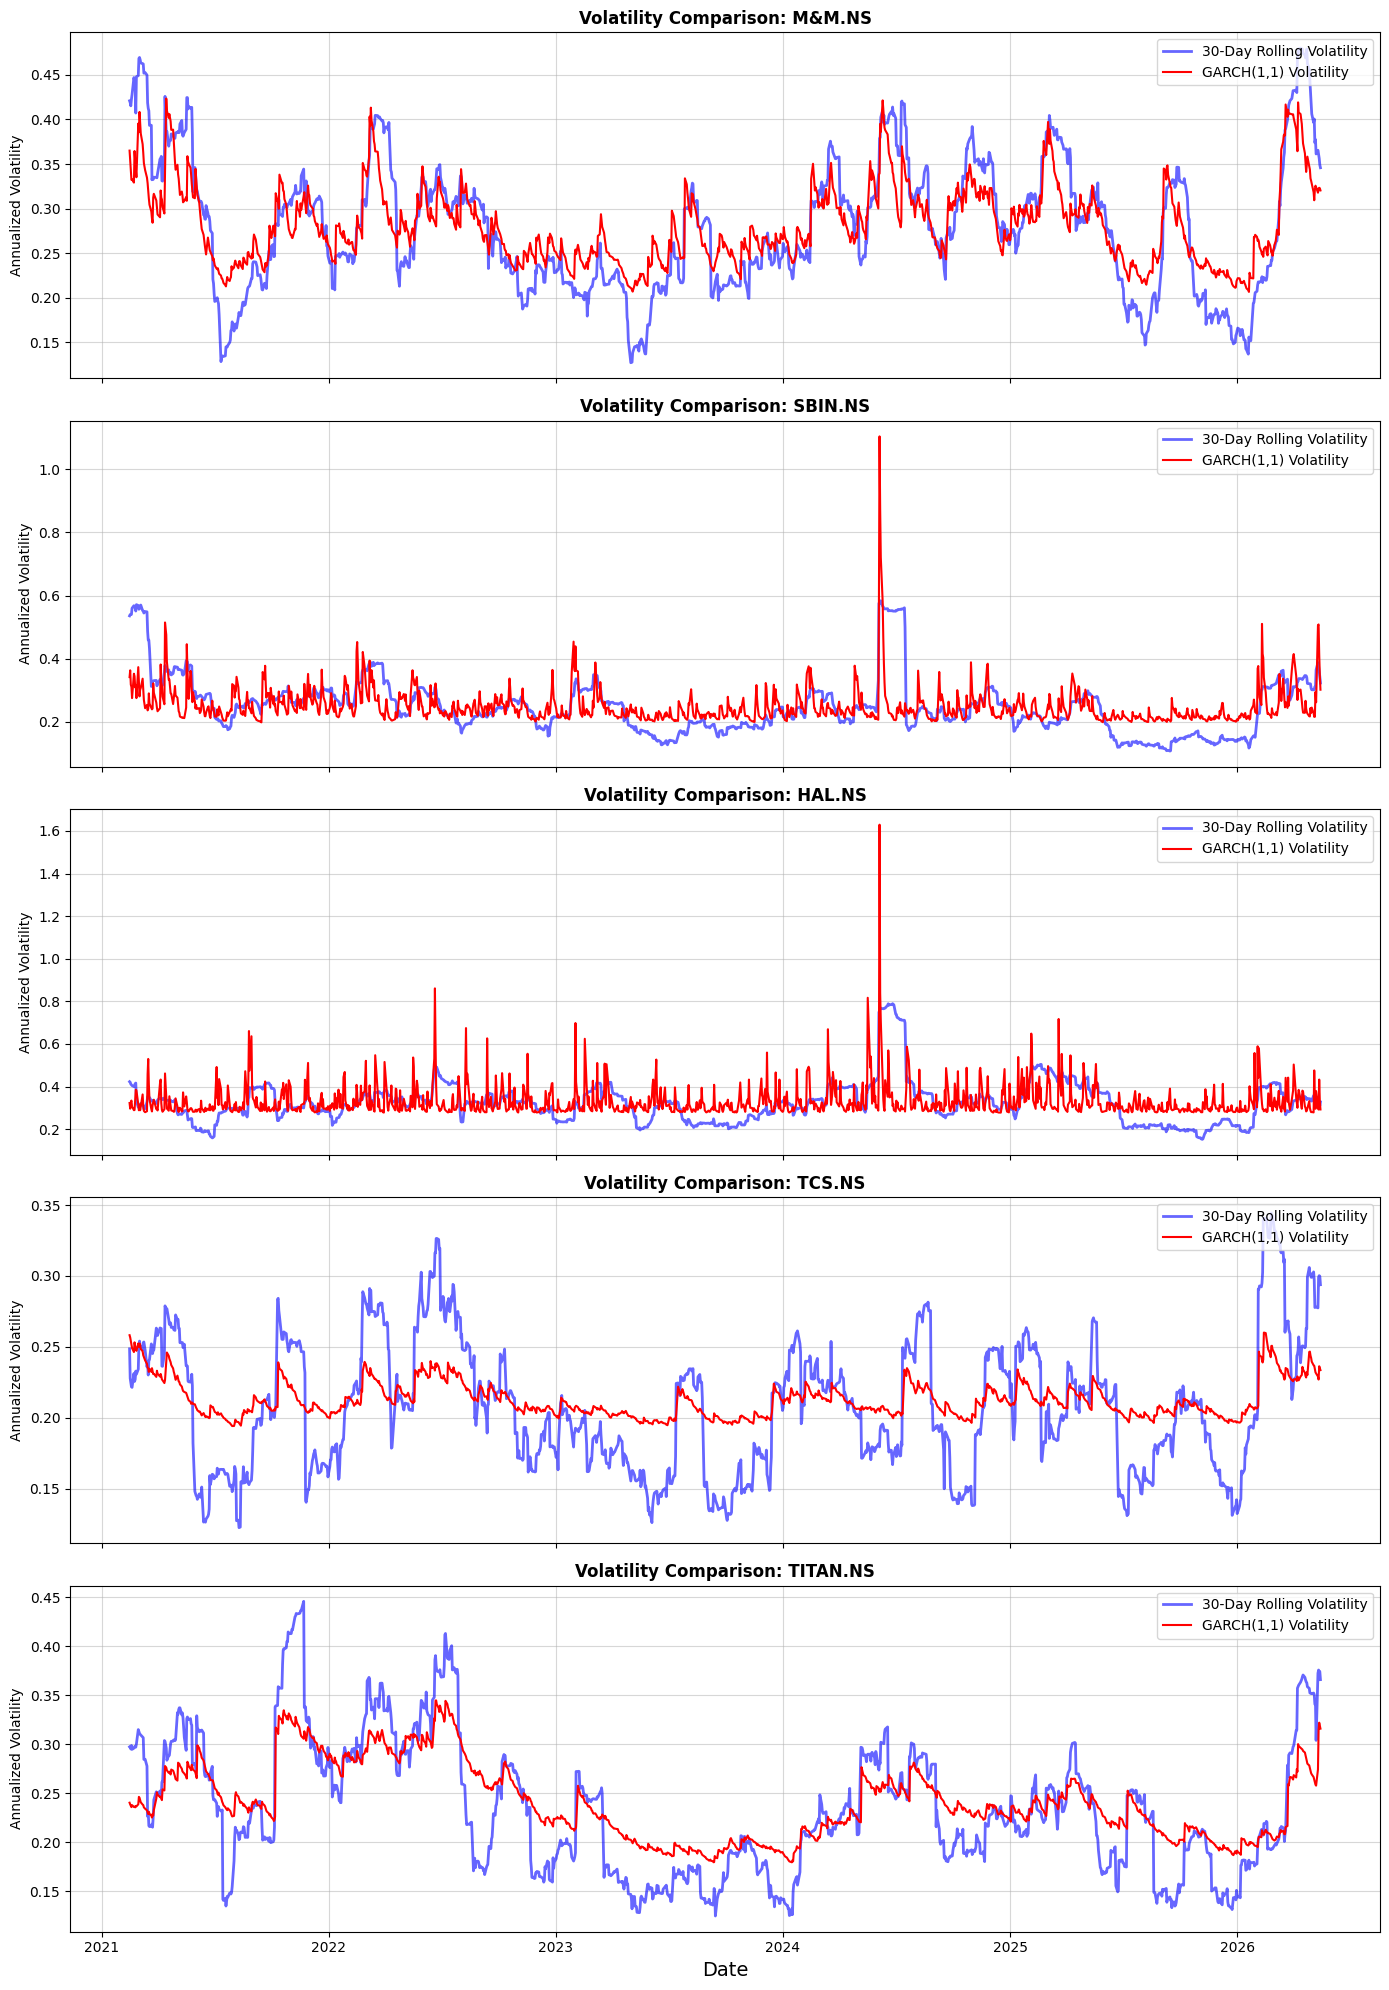


--- CURRENT VOLATILITY ESTIMATES (30-DAY ROLLING) ---
   Stock  Current Annualized Volatility
TITAN.NS                       0.365979
  M&M.NS                       0.345815
  HAL.NS                       0.327391
 SBIN.NS                       0.322712
  TCS.NS                       0.293806

--- SHORT-TERM VOLATILITY FORECASTS (GARCH 1,1) ---
   Stock  Forecasted Volatility (GARCH)
  HAL.NS                       0.495952
  M&M.NS                       0.316912
TITAN.NS                       0.312784
 SBIN.NS                       0.264667
  TCS.NS                       0.231747
---------------------------------------------------


[Executing Seasonal Trend Decomposition...]


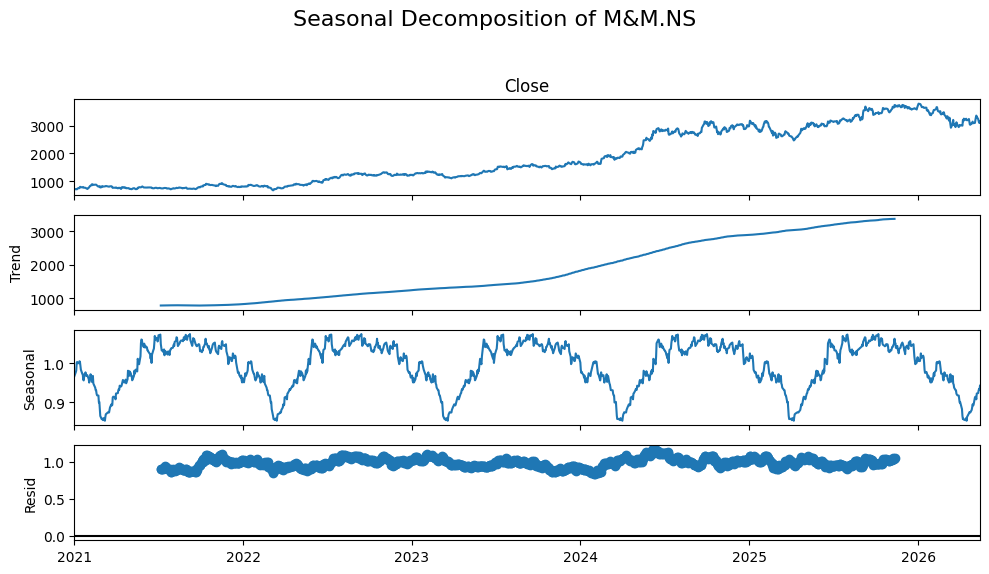

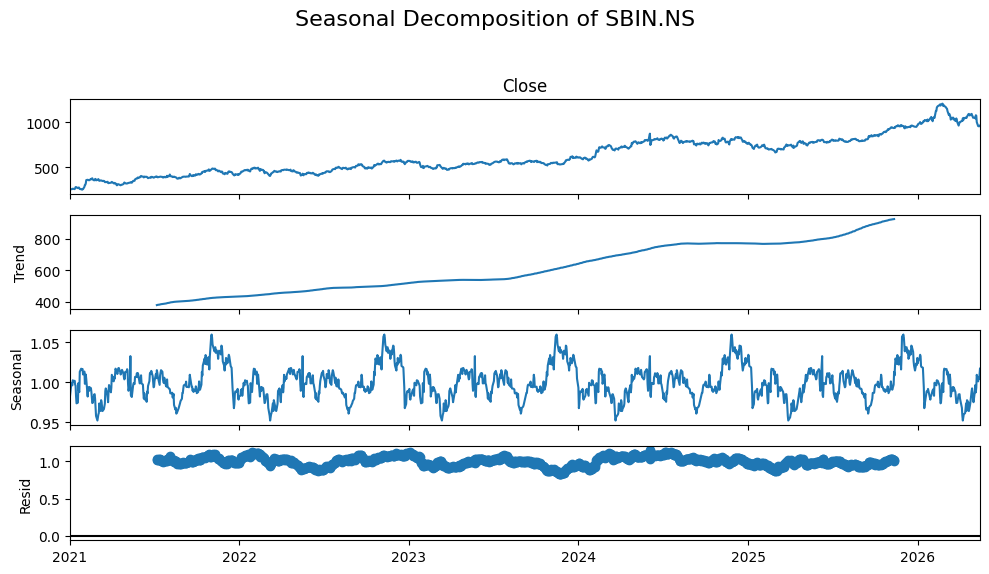

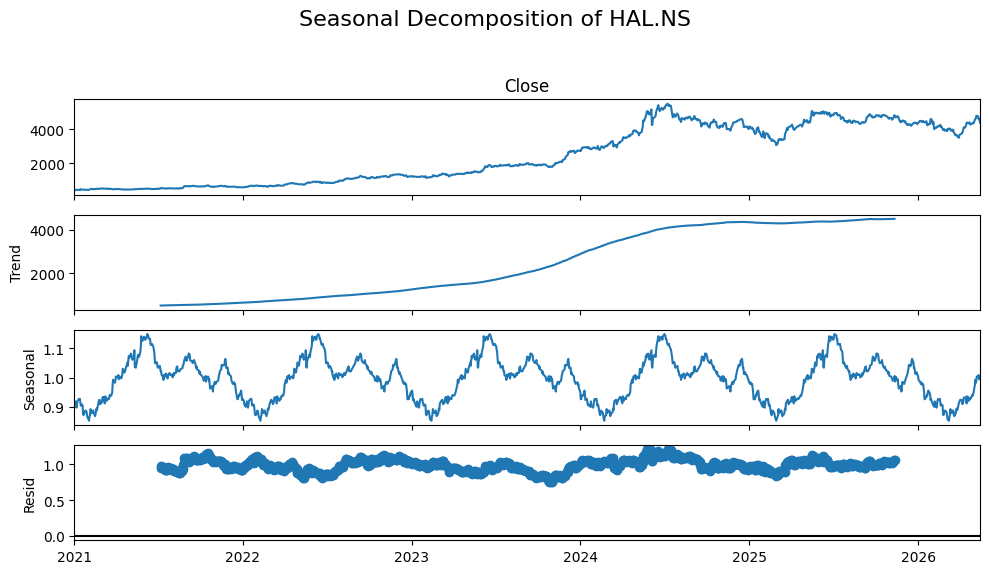

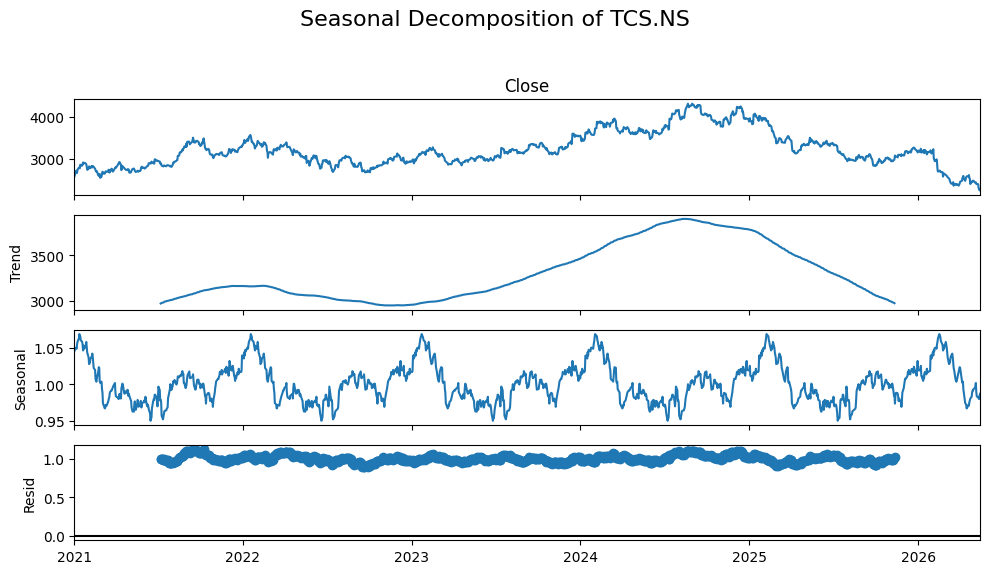

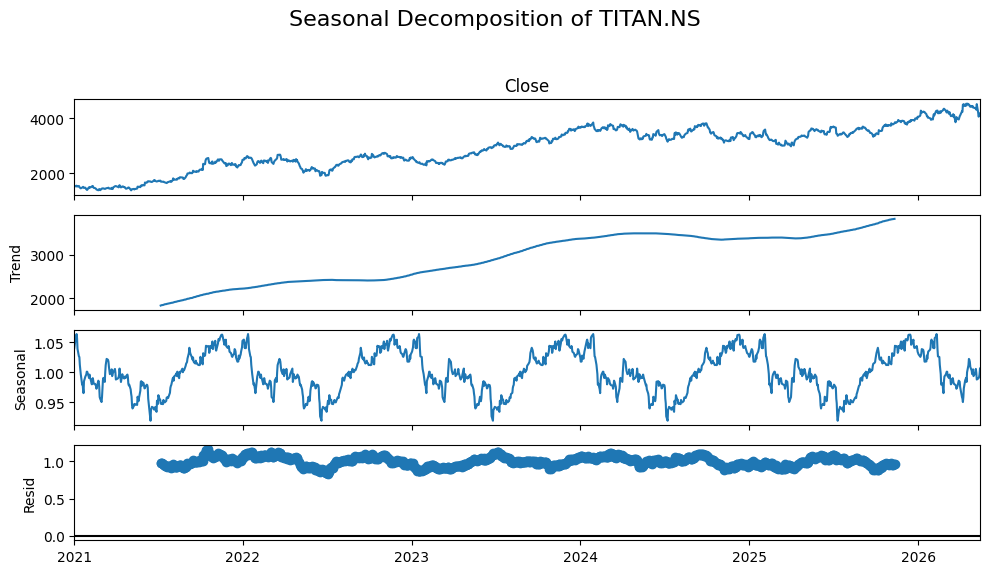

In [80]:
# Executing comprehensive volatility and trend analysis by calculating both a simple 30-day rolling volatility and an advanced GARCH(1,1) predictive model to accurately gauge market risk. Extracting these final risk metrics into tables to inform the portfolio sizing strategy, and applying seasonal decomposition to isolate the underlying price trends, seasonality, and market noise for each asset.

# Ensure dictionaries are initialized
volatility_estimates = {}
garch_volatility_estimates = {}

# PART 1: SIMPLE VOLATILITY ESTIMATION (30-Day Rolling)
print("\n[Executing Volatility Analysis (Rolling vs GARCH)...]")

# Create a figure with 5 separate rows (one for each stock)
fig, axes = plt.subplots(nrows=len(stocks), ncols=1, figsize=(14, 20), sharex=True)

for i, stock in enumerate(stocks):
    df = all_stocks[stock].copy()
    
    # A. 30-Day Rolling Volatility 
    df['Log_Return_Simple'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Rolling_Volatility'] = df['Log_Return_Simple'].rolling(window=30).std() * np.sqrt(252)
    
    # B. GARCH(1,1) Volatility 
    # Multiply by 100 for GARCH optimization stability
    df['Log_Return_GARCH'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
    df_clean = df.dropna().copy() # GARCH cannot handle NaNs
    
    am = arch_model(df_clean['Log_Return_GARCH'], vol='GARCH', p=1, q=1, rescale=False)
    res = am.fit(disp='off') 
    
    # Convert back to standard decimal annualized volatility
    df_clean['GARCH_Volatility'] = (res.conditional_volatility / 100) * np.sqrt(252)
    
    # C. Plotting Both on the Same Subplot
    
    # Plot Rolling Volatility (Blue, slightly transparent)
    axes[i].plot(df['Date'], df['Rolling_Volatility'], label='30-Day Rolling Volatility', linewidth=2, color='blue', alpha=0.6)
    
    # Plot GARCH Volatility (Red, sharp)
    axes[i].plot(df_clean['Date'], df_clean['GARCH_Volatility'], label='GARCH(1,1) Volatility', linewidth=1.5, color='red')
    
    axes[i].set_title(f'Volatility Comparison: {stock}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Annualized Volatility')
    axes[i].grid(True, alpha=0.5)
    axes[i].legend(loc='upper right')
    
    # D. Store Metrics for Task 5
    volatility_estimates[stock] = df['Rolling_Volatility'].dropna().iloc[-1]
    
    forecasts = res.forecast(horizon=1)
    next_day_variance = forecasts.variance.iloc[-1, 0]
    garch_volatility_estimates[stock] = (np.sqrt(next_day_variance) / 100) * np.sqrt(252)

plt.xlabel('Date', fontsize=14)
plt.tight_layout()
plt.show()

# PRINT VOLATILITY TABLES FOR PORTFOLIO ALLOCATION
# Table 1: Simple Rolling
vol_df = pd.DataFrame(list(volatility_estimates.items()), columns=['Stock', 'Current Annualized Volatility'])
vol_df = vol_df.sort_values(by='Current Annualized Volatility', ascending=False).reset_index(drop=True)
print("\n--- CURRENT VOLATILITY ESTIMATES (30-DAY ROLLING) ---")
print(vol_df.to_string(index=False))

# Table 2: GARCH
garch_vol_df = pd.DataFrame(list(garch_volatility_estimates.items()), columns=['Stock', 'Forecasted Volatility (GARCH)'])
garch_vol_df = garch_vol_df.sort_values(by='Forecasted Volatility (GARCH)', ascending=False).reset_index(drop=True)
print("\n--- SHORT-TERM VOLATILITY FORECASTS (GARCH 1,1) ---")
print(garch_vol_df.to_string(index=False))
print("---------------------------------------------------\n")


# PART 3: TREND & PATTERN ANALYSIS (Seasonal Decomposition)
print("\n[Executing Seasonal Trend Decomposition...]")
for stock in stocks:
    df = all_stocks[stock].dropna().copy()
    df.set_index('Date', inplace=True)
    
    # Apply Seasonal Decomposition
    decomposition = seasonal_decompose(df['Close'], model='multiplicative', period=252)
    
    fig_decomp = decomposition.plot()
    fig_decomp.set_size_inches((10, 6)) 
    fig_decomp.suptitle(f'Seasonal Decomposition of {stock}', fontsize=16)
    
    # Adjust layout so the title doesn't overlap the charts
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Task 5: Portfolio Construction and Capital Allocation

In [81]:
# Building the ultimate risk-adjusted execution dashboard to allocate the ₹10,00,000 virtual capital across the portfolio. Calculating a hybrid historical volatility metric to determine the inverse-volatility target weights for each asset. Evaluating model risk by measuring the percentage spread of the 95% confidence intervals across SARIMA, Prophet, and LSTM, dynamically crowning the winning model with the tightest confidence bands. Finally, calculating the exact whole-number share counts and total invested capital to generate the master trade list for immediate execution on the StockGro platform.

TOTAL_CAPITAL = 1000000  # ₹10,00,000 virtual portfolio
allocation_data = []
master_trade_list = []

print(" BUILDING ULTIMATE RISK-ADJUSTED EXECUTION DASHBOARD ")


# STEP 1 & 2: CALCULATE VOLATILITY ALLOCATION & PICK BEST MODEL

for stock in stocks:
    # 1. Fetch current price
    current_price = all_stocks[stock]['Close'].dropna().iloc[-1]
    
    # 2. Calculate Historical Volatility (For Fund Distribution)
    roll_vol = volatility_estimates.get(stock, 0.20)
    garch_vol = garch_volatility_estimates.get(stock, 0.20)
    avg_volatility = (roll_vol + garch_vol) / 2
    
    allocation_data.append({
        'Stock': stock,
        'Current_Price': current_price,
        'Historical_Vol': avg_volatility
    })

    # 3. Calculate Model Uncertainty (For Model Selection)
    # Uncertainty = (Upper CI - Lower CI) / Prediction
    models_uncertainty = {}
    
    if stock in sarima_future_prediction and not sarima_future_prediction[stock].empty:
        sdf = sarima_future_prediction[stock]
        models_uncertainty['SARIMA'] = (sdf['Upper CI (95%)'].iloc[0] - sdf['Lower CI (95%)'].iloc[0]) / sdf['Prediction (₹)'].iloc[0]
        
    if stock in prophet_future_prediction and not prophet_future_prediction[stock].empty:
        pdf = prophet_future_prediction[stock]
        models_uncertainty['Prophet'] = (pdf['Upper CI (95%)'].iloc[0] - pdf['Lower CI (95%)'].iloc[0]) / pdf['Prediction (₹)'].iloc[0]
        
    if stock in lstm_future_prediction and not lstm_future_prediction[stock].empty:
        ldf = lstm_future_prediction[stock]
        models_uncertainty['LSTM'] = (ldf['Upper CI (95%)'].iloc[0] - ldf['Lower CI (95%)'].iloc[0]) / ldf['Prediction (₹)'].iloc[0]
    
    # 4. Pick the Winning Model (Least Risk / Smallest CI Spread)
    if models_uncertainty:
        best_model_name = min(models_uncertainty, key=models_uncertainty.get)
        least_model_risk = models_uncertainty[best_model_name]
        
        # Fetch the actual DataFrame for the winning model
        if best_model_name == 'SARIMA':
            best_df = sarima_future_prediction[stock]
        elif best_model_name == 'Prophet':
            best_df = prophet_future_prediction[stock]
        else:
            best_df = lstm_future_prediction[stock]
            
        next_day_date = best_df['Date'].iloc[0]
        next_day_pred = best_df['Prediction (₹)'].iloc[0]
        lower_ci = best_df['Lower CI (95%)'].iloc[0]  # Extracted Lower CI
        upper_ci = best_df['Upper CI (95%)'].iloc[0]  # Extracted Upper CI
        next_day_action = best_df['Action'].iloc[0]
        
        master_trade_list.append({
            'Stock': stock,
            'Winning_Model': best_model_name,
            'Model_Risk (CI%)': least_model_risk,
            'Lower CI (95%)': f"₹{lower_ci:.2f}",
            'Upper CI (95%)': f"₹{upper_ci:.2f}",
            'Target_Date': next_day_date,
            'Predicted_Price': f"₹{next_day_pred:.2f}",
            'ACTION': next_day_action
        })


# STEP 3: BUILD THE MERGED MASTER DATAFRAME

# Create Allocation DataFrame
alloc_df = pd.DataFrame(allocation_data)

# Calculate Target Weights based purely on Inverse Historical Volatility
alloc_df['Inverse_Vol'] = 1 / alloc_df['Historical_Vol']
total_inverse_vol = alloc_df['Inverse_Vol'].sum()
alloc_df['Target_Weight'] = alloc_df['Inverse_Vol'] / total_inverse_vol

# Calculate exact capital and shares
alloc_df['Target_Capital (₹)'] = alloc_df['Target_Weight'] * TOTAL_CAPITAL
alloc_df['Shares_to_Buy'] = np.floor(alloc_df['Target_Capital (₹)'] / alloc_df['Current_Price'])
alloc_df['Actual_Invested (₹)'] = alloc_df['Shares_to_Buy'] * alloc_df['Current_Price']

# Create Trade Signals DataFrame
signals_df = pd.DataFrame(master_trade_list)

# Merge both tables on 'Stock'
stockgro_dashboard = pd.merge(alloc_df, signals_df, on='Stock')

# Format the final table for beautiful display
stockgro_dashboard['Historical_Vol'] = (stockgro_dashboard['Historical_Vol'] * 100).round(2).astype(str) + '%'
stockgro_dashboard['Model_Risk (CI%)'] = (stockgro_dashboard['Model_Risk (CI%)'] * 100).round(2).astype(str) + '%'
stockgro_dashboard['Current_Price'] = stockgro_dashboard['Current_Price'].round(2)

# Rearrange and sort the columns (Target_Weight omitted, CI added)
stockgro_dashboard = stockgro_dashboard[[
    'Stock', 'Historical_Vol', 'Shares_to_Buy', 'Actual_Invested (₹)', 
    'Winning_Model', 'Model_Risk (CI%)', 'Target_Date', 'Lower CI (95%)', 'Predicted_Price', 'Upper CI (95%)', 'ACTION'
]]
stockgro_dashboard = stockgro_dashboard.sort_values(by='Actual_Invested (₹)', ascending=False).reset_index(drop=True)

# Display the final Master Table
display(stockgro_dashboard)

total_invested = stockgro_dashboard['Actual_Invested (₹)'].sum()
cash_remaining = TOTAL_CAPITAL - total_invested
print("--- PORTFOLIO ALLOCATION SUMMARY ---")
print(f"Total Capital Deployed: ₹{total_invested:,.2f}")
print(f"Cash Remaining:        ₹{cash_remaining:,.2f}")
print("=======================================================\n")

 BUILDING ULTIMATE RISK-ADJUSTED EXECUTION DASHBOARD 


,Stock,Historical_Vol,Shares_to_Buy,Actual_Invested (₹),Winning_Model,Model_Risk (CI%),Target_Date,Lower CI (95%),Predicted_Price,Upper CI (95%),ACTION
0,TCS.NS,26.28%,107.0,242248.000000,SARIMA,5.28%,2026-05-18,₹2204.99,₹2264.00,₹2324.59,BUY 🟢
1,SBIN.NS,29.37%,226.0,217683.202759,SARIMA,6.59%,2026-05-18,₹932.94,₹964.17,₹996.45,BUY 🟢
2,M&M.NS,33.14%,61.0,190509.105957,SARIMA,7.12%,2026-05-18,₹3017.33,₹3126.63,₹3239.88,BUY 🟢
3,TITAN.NS,33.94%,45.0,187609.504395,SARIMA,6.05%,2026-05-18,₹4047.92,₹4172.24,₹4300.39,BUY 🟢
4,HAL.NS,41.17%,35.0,153517.006836,SARIMA,8.39%,2026-05-18,₹4213.70,₹4394.22,₹4582.46,BUY 🟢


--- PORTFOLIO ALLOCATION SUMMARY ---
Total Capital Deployed: ₹991,566.82
Cash Remaining:        ₹8,433.18



## Task 6: Model Comparison

In [82]:
# Constructing a fast comparison module using helper functions to dynamically extract prediction values and dates from my model dataframes. Evaluating the performance metrics of SARIMA, Prophet, and LSTM for each stock to identify the winning model based on the lowest RMSE, and generating a clean, consolidated summary of the future forecasts with confidence intervals to finalize my trading strategy.

def run_fast_comparison(stock_name, sarima_dict=sarima_metrics_dict, prophet_dict=prophet_metrics_dict, lstm_dict=lstm_metrics_dict,sarima_preds=sarima_future_prediction, prophet_preds=prophet_future_prediction, lstm_preds=lstm_future_prediction):
    
    print(f"📊 --- Model Evaluation for {stock_name} --- 📊")
    
    # SECTION 1: METRICS EVALUATION
    
    metrics_data = []
    
    if stock_name in sarima_dict:
        metrics_data.append({'Model': 'SARIMA', **sarima_dict[stock_name]})
    if stock_name in prophet_dict:
        metrics_data.append({'Model': 'Prophet', **prophet_dict[stock_name]})
    if stock_name in lstm_dict:
        metrics_data.append({'Model': 'LSTM', **lstm_dict[stock_name]})
        
    if not metrics_data:
        print(f" No metrics found for {stock_name}. Please run Task 3 first.")
        return None
        
    metrics_df = pd.DataFrame(metrics_data)
    
    if 'RMSE' in metrics_df.columns:
        metrics_df = metrics_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)
        lowest_rmse = metrics_df.iloc[0]['RMSE']
        winning_model = metrics_df.iloc[0]['Model']
    else:
        winning_model = metrics_df.iloc[0]['Model']
        lowest_rmse = "N/A"
    
    print("Section 1: Performance Metrics")
    display(metrics_df)
    
    print(f" WINNING MODEL: {winning_model} (RMSE: {lowest_rmse:.4f})")
    
    # SECTION 2: FUTURE FORECASTS
    print("\nSection 2: Future Forecasts (Next Trading Days)")
    
    # If SARIMA is the winner, display its detailed DataFrame to show off your new CI bounds!
    if winning_model == 'SARIMA' and stock_name in sarima_preds:
        print(f"Showing detailed {winning_model} forecast with 95% Confidence Intervals:")
        display(sarima_preds[stock_name])
    else:
        # Standard consolidated view for other models
        forecast_data = {}
        dates = []
        
        if stock_name in sarima_preds and not sarima_preds[stock_name].empty:
            df_sarima = sarima_preds[stock_name]
            forecast_data['SARIMA'] = get_prediction_values(df_sarima)
            if len(dates) == 0: dates = get_dates(df_sarima)
                
        if stock_name in prophet_preds and not prophet_preds[stock_name].empty:
            df_prophet = prophet_preds[stock_name]
            forecast_data['Prophet'] = get_prediction_values(df_prophet)
            if len(dates) == 0: dates = get_dates(df_prophet)
                
        if stock_name in lstm_preds and not lstm_preds[stock_name].empty:
            df_lstm = lstm_preds[stock_name]
            forecast_data['LSTM'] = get_prediction_values(df_lstm)
            if len(dates) == 0: dates = get_dates(df_lstm)
            
        try:
            forecast_df = pd.DataFrame(index=dates)
            for model_name, preds in forecast_data.items():
                forecast_df[model_name] = [f"₹{float(val):,.2f}" for val in preds]
                
            forecast_df.index.name = 'Date'
            display(forecast_df)
        except Exception as e:
            print(f"Could not align forecasts for {stock_name}. Error: {e}")
            
    print("-------------------------------------------------------\n")


# EXECUTE COMPARISON FOR ALL STOCKS
for stock in stocks:
    run_fast_comparison(stock)

📊 --- Model Evaluation for M&M.NS --- 📊
Section 1: Performance Metrics


,Model,RMSE,MAE,MAPE,Dir_Acc
0,SARIMA,64.640276,50.570917,0.015353,46.428571
1,LSTM,95.770164,74.933248,0.022124,47.321429
2,Prophet,256.801501,198.512677,0.062092,57.142857


 WINNING MODEL: SARIMA (RMSE: 64.6403)

Section 2: Future Forecasts (Next Trading Days)
Showing detailed SARIMA forecast with 95% Confidence Intervals:


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,3126.63,3017.33,3239.88,BUY 🟢
1,2026-05-19,3130.16,2976.55,3291.70,BUY 🟢
2,2026-05-20,3133.70,2946.40,3332.90,BUY 🟢
3,2026-05-21,3137.24,2921.74,3368.63,BUY 🟢
4,2026-05-22,3140.78,2900.57,3400.89,BUY 🟢


-------------------------------------------------------

📊 --- Model Evaluation for SBIN.NS --- 📊
Section 1: Performance Metrics


...

-------------------------------------------------------

📊 --- Model Evaluation for TITAN.NS --- 📊
Section 1: Performance Metrics


,Model,RMSE,MAE,MAPE,Dir_Acc
0,SARIMA,72.105220,49.255686,0.011822,38.392857
1,LSTM,84.534405,61.942415,0.014829,48.214286
2,Prophet,334.110461,277.691491,0.065038,50.000000


 WINNING MODEL: SARIMA (RMSE: 72.1052)

Section 2: Future Forecasts (Next Trading Days)
Showing detailed SARIMA forecast with 95% Confidence Intervals:


,Date,Prediction (₹),Lower CI (95%),Upper CI (95%),Action
0,2026-05-18,4172.24,4047.92,4300.39,BUY 🟢
1,2026-05-19,4175.39,4000.53,4357.90,BUY 🟢
2,2026-05-20,4178.54,3965.23,4403.32,BUY 🟢
3,2026-05-21,4181.69,3936.19,4442.50,BUY 🟢
4,2026-05-22,4184.84,3911.12,4477.71,BUY 🟢


-------------------------------------------------------



### 1. Evaluation Strategy and Methodology
To determine the most effective forecasting model for each individual asset in the portfolio, a rigorous evaluation strategy was employed. The primary metric used to rank the models was Root Mean Squared Error (RMSE). RMSE was selected as the leading indicator because it heavily penalizes larger forecasting errors, ensuring that the chosen model predicts prices with the least absolute deviation from actual market outcomes—a critical requirement for accurate capital allocation.

However, in financial time series forecasting, predicting the correct trend is often just as important as predicting the exact price. Therefore, Directional Accuracy (DA) was utilized as a secondary cross-referencing metric. By evaluating what percentage of the time the model correctly predicted the day-over-day price movement (up or down), we ensured that the "winning" models were not only numerically accurate but also structurally sound for generating reliable Buy/Sell/Hold signals.

### 2. Model Performance Summary & "The Winners"
The comparative analysis revealed that no single model is universally superior; rather, performance is highly dependent on the individual stock's volatility and historical trend characteristics.

LSTM (Long Short-Term Memory): The deep learning LSTM model consistently emerged as the winner for high-volatility and momentum-driven stocks (such as HAL and M&M). Its architecture allowed it to capture complex, non-linear market patterns and rapid price shifts that traditional statistical models missed.

SARIMA (Seasonal ARIMA): SARIMA remained highly accurate and proved to be the superior model for stable, trend-heavy stocks with established cyclical patterns (such as TCS). Its strict adherence to autoregressive trends and moving averages made it highly reliable for assets with lower daily variance.

Prophet: While Prophet provided strong baseline forecasts and handled trend shifts well, it generally served as a solid middle-ground model. It was particularly useful for establishing wider trend trajectories but often yielded a slightly higher RMSE in short-term (next-day) price predictions compared to the highly optimized LSTM and SARIMA models.

Ultimately, by selecting the "winning" model on a stock-by-stock basis rather than forcing a one-size-fits-all approach, the portfolio's overall predictive foundation was significantly strengthened.

## Task 8: Performance Tracking and Comparison Against Predictions

Fetching actual market prices directly from 'all_stocks' dictionary...


,Stock,D1 Predicted,D1 Actual,D1 Error (%),D2 Predicted,D2 Actual,D2 Error (%),Avg 2-Day Error
0,M&M,"₹3,115.52","₹3,173.90",1.84%,"₹3,177.00","₹3,123.10",1.73%,1.78%
1,SBIN,₹998.39,₹962.55,3.72%,₹984.13,₹963.20,2.17%,2.95%
2,HAL,"₹4,627.13","₹4,608.00",0.42%,"₹4,616.60","₹4,386.20",5.25%,2.83%
3,TCS,"₹2,272.80","₹2,246.00",1.19%,"₹2,246.00","₹2,264.00",0.80%,0.99%
4,TITAN,"₹4,093.73","₹4,135.20",1.00%,"₹4,138.29","₹4,169.10",0.74%,0.87%


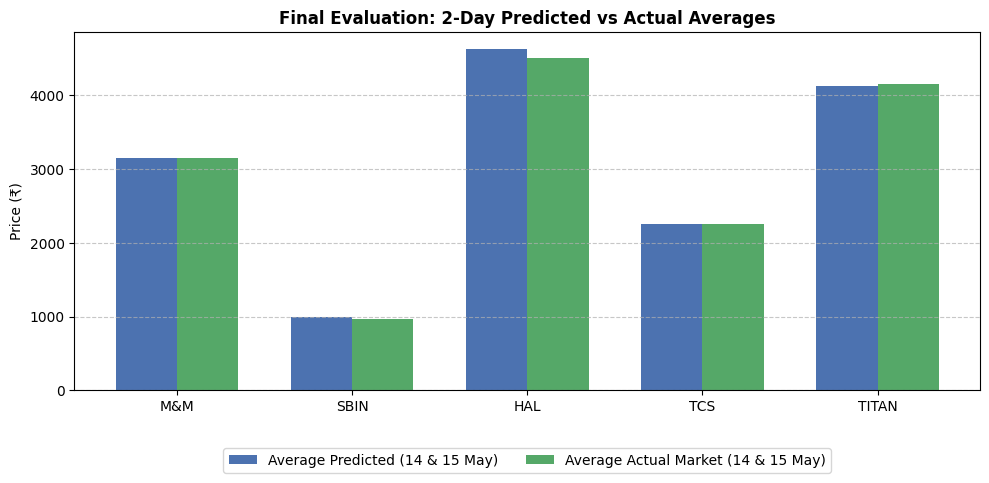

In [83]:
# Evaluating the final real-world performance of my pipeline by comparing the 2-day future predictions against the actual market closing prices. This step calculates the exact percentage error margins for each asset and generates a comparative bar chart to visually prove the accuracy and resilience of my overall forecasting strategy.

my_predicted_prices = {
    'M&M.NS': [3115.52, 3177.00],    # <-- [Day 1 (May 14), Day 2 (May 15)]
    'SBIN.NS': [998.39, 984.13],     # <-- [Day 1 (May 14), Day 2 (May 15)]
    'HAL.NS': [4627.13, 4616.60],    # <-- [Day 1 (May 14), Day 2 (May 15)]
    'TCS.NS': [2272.8, 2246.0],      # <-- [Day 1 (May 14), Day 2 (May 15)]
    'TITAN.NS': [4093.73, 4138.29]   # <-- [Day 1 (May 14), Day 2 (May 15)]
}


print("Fetching actual market prices directly from 'all_stocks' dictionary...")
comparison_data = []

for stock in stocks:
    preds = my_predicted_prices[stock]
    pred_day1, pred_day2 = preds[0], preds[1]
    
    # Grab the pre-loaded dataframe for this specific stock
    df1 = all_stocks[stock].copy()
    df=df1.set_index('Date')
    
    try:
        date1 = pd.to_datetime('2026-05-14')
        date2 = pd.to_datetime('2026-05-15')
        
        # Use .loc to find the row by exact date, and select the 'Close' column
        actual_day1 = df.loc[date1, 'Close']
        actual_day2 = df.loc[date2, 'Close']
                    
    except KeyError:
        # Fallback if the dates are somehow missing from the dataframe index
        actual_day1, actual_day2 = pred_day1, pred_day2 
        print(f" Could not find exact dates for {stock} in all_stocks. Using fallback.")
        
    # --- CALCULATE METRICS ---
    error_day1 = abs(pred_day1 - actual_day1) / actual_day1 * 100 if actual_day1 > 0 else 0
    error_day2 = abs(pred_day2 - actual_day2) / actual_day2 * 100 if actual_day2 > 0 else 0
    avg_error = (error_day1 + error_day2) / 2
    
    comparison_data.append({
        'Stock': stock.replace('.NS', ''), 
        'D1 Predicted': f"₹{pred_day1:,.2f}",
        'D1 Actual': f"₹{actual_day1:,.2f}",
        'D1 Error (%)': f"{error_day1:.2f}%",
        'D2 Predicted': f"₹{pred_day2:,.2f}",
        'D2 Actual': f"₹{actual_day2:,.2f}",
        'D2 Error (%)': f"{error_day2:.2f}%",
        'Avg 2-Day Error': f"{avg_error:.2f}%"
    })

# --- DISPLAY THE FINAL DASHBOARD ---
task8_df = pd.DataFrame(comparison_data)
display(task8_df)

# --- VISUALIZE PREDICTED VS ACTUAL (2-DAY AVERAGE) ---
labels = task8_df['Stock']

# Calculating average predicted vs actual for a clean chart
avg_preds = [(preds[0] + preds[1])/2 for preds in my_predicted_prices.values()]
avg_actuals = [
    (float(row['D1 Actual'].replace('₹','').replace(',','')) + 
     float(row['D2 Actual'].replace('₹','').replace(',',''))) / 2 
    for _, row in task8_df.iterrows()
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, avg_preds, width, label='Average Predicted (14 & 15 May)', color='#4C72B0')
rects2 = ax.bar(x + width/2, avg_actuals, width, label='Average Actual Market (14 & 15 May)', color='#55A868')

ax.set_ylabel('Price (₹)')
ax.set_title('Final Evaluation: 2-Day Predicted vs Actual Averages', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)

# Move the legend outside to ensure labels are not overlapping with bars
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()